In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Carichiamo le stazioni di misurazione NO2
stations = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\NO2 metingen locaties_geojson_latlng.json")

print(f"Stazioni caricate: {len(stations)}")
print(stations.columns.tolist())
stations.head()

Stazioni caricate: 490
['Code', 'Locatie', 'Type_meetpunt', 'Afstand_tot_gevel_m', 'Meting_op_wettelijke_toetsafstand', 'Type_meting', 'Opmerkingen', 'geometry']


,Code,Locatie,Type_meetpunt,Afstand_tot_gevel_m,Meting_op_wettelijke_toetsafstand,Type_meting,Opmerkingen,geometry
0,1HDG17,1e Hugo de Grootstraat 17,Achtergrond,0.0,,Palmes,,POINT (52.37596 4.87429)
1,ESW/G,A10-West aan balkon Jephtastraat,Snelweg,1.5,nee,Palmes,,POINT (52.38134 4.84528)
2,AD14,Adelaarsweg 14,Straat,3.0,nee,Palmes,,POINT (52.38443 4.91197)
3,AD7,Adelaarsweg 7,Straat,3.0,nee,Palmes,,POINT (52.38404 4.91145)
4,ADM58,Admiraliteitsstraat 58,Achtergrond,0.0,,Palmes,,POINT (52.3687 4.9248)


In [2]:
print("Tipi di punto di misura:")
print(stations['Type_meetpunt'].value_counts())

print("\nTipi di misurazione:")
print(stations['Type_meting'].value_counts())

Tipi di punto di misura:
Type_meetpunt
Straat         320
Achtergrond    108
Snelweg         40
Industrie       10
Waterweg         9
Luchtvaart       3
Name: count, dtype: int64

Tipi di misurazione:
Type_meting
Palmes                 471
Automatisch meetnet     19
Name: count, dtype: int64


In [3]:
# Carichiamo il CSV delle misurazioni annuali
no2 = pd.read_csv(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\NO2_JAREN.csv", 
                  sep=';', encoding='latin-1')

print(f"Righe caricate: {len(no2)}")
print(no2.columns.tolist())
no2.head()

Righe caricate: 484
['ï»¿OBJECTNUMMER', 'CodeJ', '_2025', '_2024', '_2023', '_2022', '_2021', '_2020', '_2019', '_2018', '_2017', '_2016', '_2015', '_2014', '_2013', '_2012', '_2011', '_2010', 'WKT_LNG_LAT', 'WKT_LAT_LNG', 'LNG', 'LAT']


,ï»¿OBJECTNUMMER,CodeJ,_2025,_2024,_2023,_2022,_2021,_2020,_2019,_2018,...,_2015,_2014,_2013,_2012,_2011,_2010,WKT_LNG_LAT,WKT_LAT_LNG,LNG,LAT
0,1,1HDG17,15.7,16.0,16.2,19.1,20.3,19.8,24.7,26.4,...,26.1,26.2,27.4,30.6,28.3,30.3,0,0,0,0
1,2,ESW/G,0.0,0.0,0.0,0.0,0.0,27.8,34.6,38.7,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
2,3,AD14,20.4,21.5,22.5,25.7,26.4,25.1,29.7,34.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
3,4,AD7,20.3,22.3,23.7,27.0,26.9,28.2,33.0,39.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
4,5,ADM58,14.5,14.5,15.4,18.2,17.8,18.6,23.1,23.2,...,25.1,28.0,26.0,29.6,29.5,28.9,0,0,0,0


In [4]:
# Puliamo il nome della prima colonna
no2.columns = [c.replace('ï»¿', '') for c in no2.columns]

# Uniamo con le stazioni usando il codice
# Prima correggiamo le coordinate delle stazioni
from shapely.ops import transform

stations_fixed = stations.copy()
stations_fixed['geometry'] = stations_fixed['geometry'].apply(
    lambda geom: transform(lambda x, y: (y, x), geom)
)
stations_fixed = stations_fixed.set_crs("EPSG:4326")
stations_fixed = stations_fixed.to_crs("EPSG:28992")

# Aggiungiamo coordinate x,y
stations_fixed['x'] = stations_fixed.geometry.x
stations_fixed['y'] = stations_fixed.geometry.y

# Uniamo i dataset
no2_geo = stations_fixed.merge(no2, left_on='Code', right_on='CodeJ', how='inner')

print(f"Stazioni con dati NO2: {len(no2_geo)}")
print(f"\nValori NO2 2024 — media: {no2_geo['_2024'].mean():.1f} µg/m³")
print(f"Valori NO2 2024 — massimo: {no2_geo['_2024'].max():.1f} µg/m³")
print(f"Valori NO2 2024 — minimo: {no2_geo['_2024'][no2_geo['_2024'] > 0].min():.1f} µg/m³")

Stazioni con dati NO2: 484

Valori NO2 2024 — media: 14.2 µg/m³
Valori NO2 2024 — massimo: 29.8 µg/m³
Valori NO2 2024 — minimo: 8.1 µg/m³


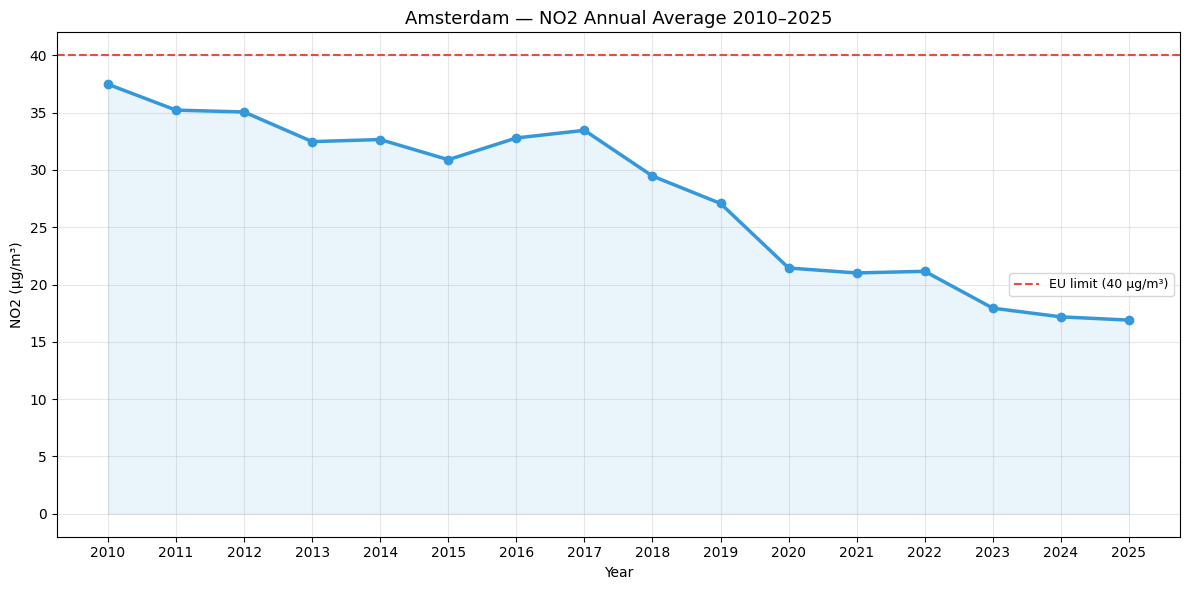

In [5]:
# Trend storico NO2 per Amsterdam
anni = [str(a) for a in range(2010, 2026)]
colonne = [f'_{a}' for a in range(2010, 2026)]

medie = []
for col in colonne:
    valori_validi = no2_geo[col][no2_geo[col] > 0]
    medie.append(valori_validi.mean())

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(anni, medie, color='#3498db', linewidth=2.5, marker='o', markersize=6)
ax.axhline(y=40, color='#e74c3c', linestyle='--', linewidth=1.5, label='EU limit (40 µg/m³)')
ax.fill_between(anni, medie, alpha=0.1, color='#3498db')
ax.set_title('Amsterdam — NO2 Annual Average 2010–2025', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('NO2 (µg/m³)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('amsterdam_no2_trend.png', dpi=150, bbox_inches='tight')
plt.show()

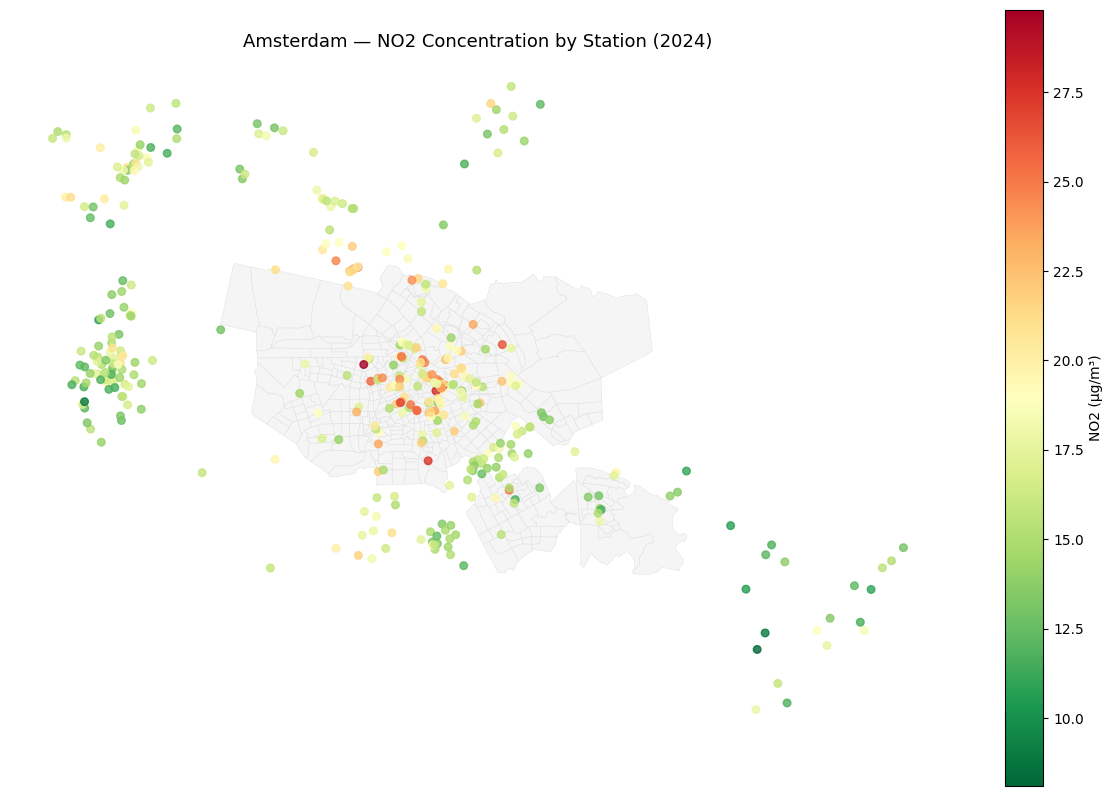

In [6]:
# Mappa NO2 2024 per stazione
no2_2024 = no2_geo[no2_geo['_2024'] > 0].copy()

buurten = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\geojson_lnglat_2.json")
buurten_proj = buurten.to_crs("EPSG:28992")

fig, ax = plt.subplots(figsize=(12, 10))

buurten_proj.plot(ax=ax, color='#f5f5f5', edgecolor='#dddddd', linewidth=0.3)

no2_2024.plot(
    column='_2024',
    cmap='RdYlGn_r',
    ax=ax,
    markersize=30,
    legend=True,
    legend_kwds={'label': 'NO2 (µg/m³)', 'shrink': 0.8},
    alpha=0.8
)

ax.set_title('Amsterdam — NO2 Concentration by Station (2024)', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('amsterdam_no2_map.png', dpi=150, bbox_inches='tight')
plt.show()